# Fictalent · Auditoria de qualidade · fechamento
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** consolidar os registros de achados dos nove notebooks de domínio (`00` a `08`), confrontar as seis declarações do cliente sobre a qualidade dos próprios dados ([`docs/02`](../../docs/02_entendimento_dados.md), seção 11) com o que a auditoria encontrou, listar os defeitos do pipeline que a auditoria achou e corrigiu, e entregar o catálogo preliminar: a lista de achados por severidade que o passo seguinte (o catálogo de achados, aprovado antes de qualquer transformação) vai decidir.

**Base analisada:** os arquivos `dados/auditoria/<dominio>.json` gravados pelos notebooks de domínio, todos sobre a mesma carga da bronze (a data de referência de cada um está no arquivo). Este notebook não abre o lake: ele lê o que os outros mediram.

**Regra desta auditoria: às cegas.** Nenhum notebook consultou o gerador da base sintética nem a régua de validação. As declarações do cliente entraram como hipóteses, e é aqui que cada uma recebe o veredito.

**Perguntas-guia:**

1. Quantos achados, de que severidade, em que domínio?
2. Das seis declarações do cliente, quais se confirmaram, com que número, e o que apareceu que ninguém declarou?
3. O que a auditoria encontrou de errado no próprio pipeline?
4. O que vai para o catálogo de achados, e em que ordem?

**Sumário:**

1. [Configuração](#secao-1)
2. [Os nove domínios](#secao-2)
3. [As seis declarações do cliente](#secao-3)
4. [Os defeitos do pipeline](#secao-4)
5. [O catálogo preliminar](#secao-5)
6. [Fechamento](#secao-6)

<a id="secao-1"></a>

# 1. Configuração

Só o pacote do projeto e os registros gravados em `dados/auditoria/`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from rh_fictalent.auditoria import achados

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (11, 4.5)
print(f"Python {sys.version.split()[0]}; pandas {pd.__version__}; matplotlib {matplotlib.__version__}")

todos = achados.carregar()
quadro = achados.consolidar(todos)
referencias = {p.name: json.loads(p.read_text(encoding="utf-8"))["referencia"] for p in sorted(achados.PASTA.glob("*.json"))}
print(f"{len(todos)} achados em {quadro['dominio'].nunique()} domínios; referências distintas: {len(set(referencias.values()))}")
for nome, ref in referencias.items():
    print(f"  {nome:<22} referência {ref[:16]}")

Python 3.12.3; pandas 3.0.5; matplotlib 3.11.2
61 achados em 9 domínios; referências distintas: 1
  ats.json               referência 2026-09-24T15:02
  cadastro.json          referência 2026-09-24T15:02
  comercial.json         referência 2026-09-24T15:02
  financeiro.json        referência 2026-09-24T15:02
  folha.json             referência 2026-09-24T15:02
  pessoas.json           referência 2026-09-24T15:02
  ponto.json             referência 2026-09-24T15:02
  seguranca.json         referência 2026-09-24T15:02
  treinamento_sst.json   referência 2026-09-24T15:02


## Nota Técnica

**Observado:** 61 achados em 9 registros, um por domínio (treinamento e SST num só), todos sobre a mesma carga da bronze (a mesma marca d'água em todos os arquivos).

**Por que importa:** registros de cargas diferentes não seriam somáveis; a data de referência igual em todos é o que permite consolidar.

**Ação:** nenhuma.

<a id="secao-2"></a>

# 2. Os nove domínios

Quantos achados por domínio e severidade, e onde as linhas atingidas se concentram. A tabela lê os registros; nada é digitado.

In [2]:
por_dominio = quadro.pivot_table(index="dominio", columns="severidade", values="achado", aggfunc="count", fill_value=0)
por_dominio = por_dominio.reindex(columns=[s for s in achados.SEVERIDADES if s in por_dominio.columns])
por_dominio["total"] = por_dominio.sum(axis=1)
por_dominio.loc["total"] = por_dominio.sum()
print(por_dominio.to_string())
print()
print(achados.resumir(todos).to_string(index=False))

severidade       alta  media  baixa  nenhuma  total
dominio                                            
ats                 1      4      3        2     10
cadastro            0      1      1        3      5
comercial           0      1      2        1      4
financeiro          1      2      4        3     10
folha               0      1      2        2      5
pessoas             1      2      1        3      7
ponto               0      2      2        4      8
seguranca           0      1      2        2      5
treinamento_sst     1      3      2        1      7
total               4     17     19       21     61

severidade  achados
      alta        4
     media       17
     baixa       19
   nenhuma       21


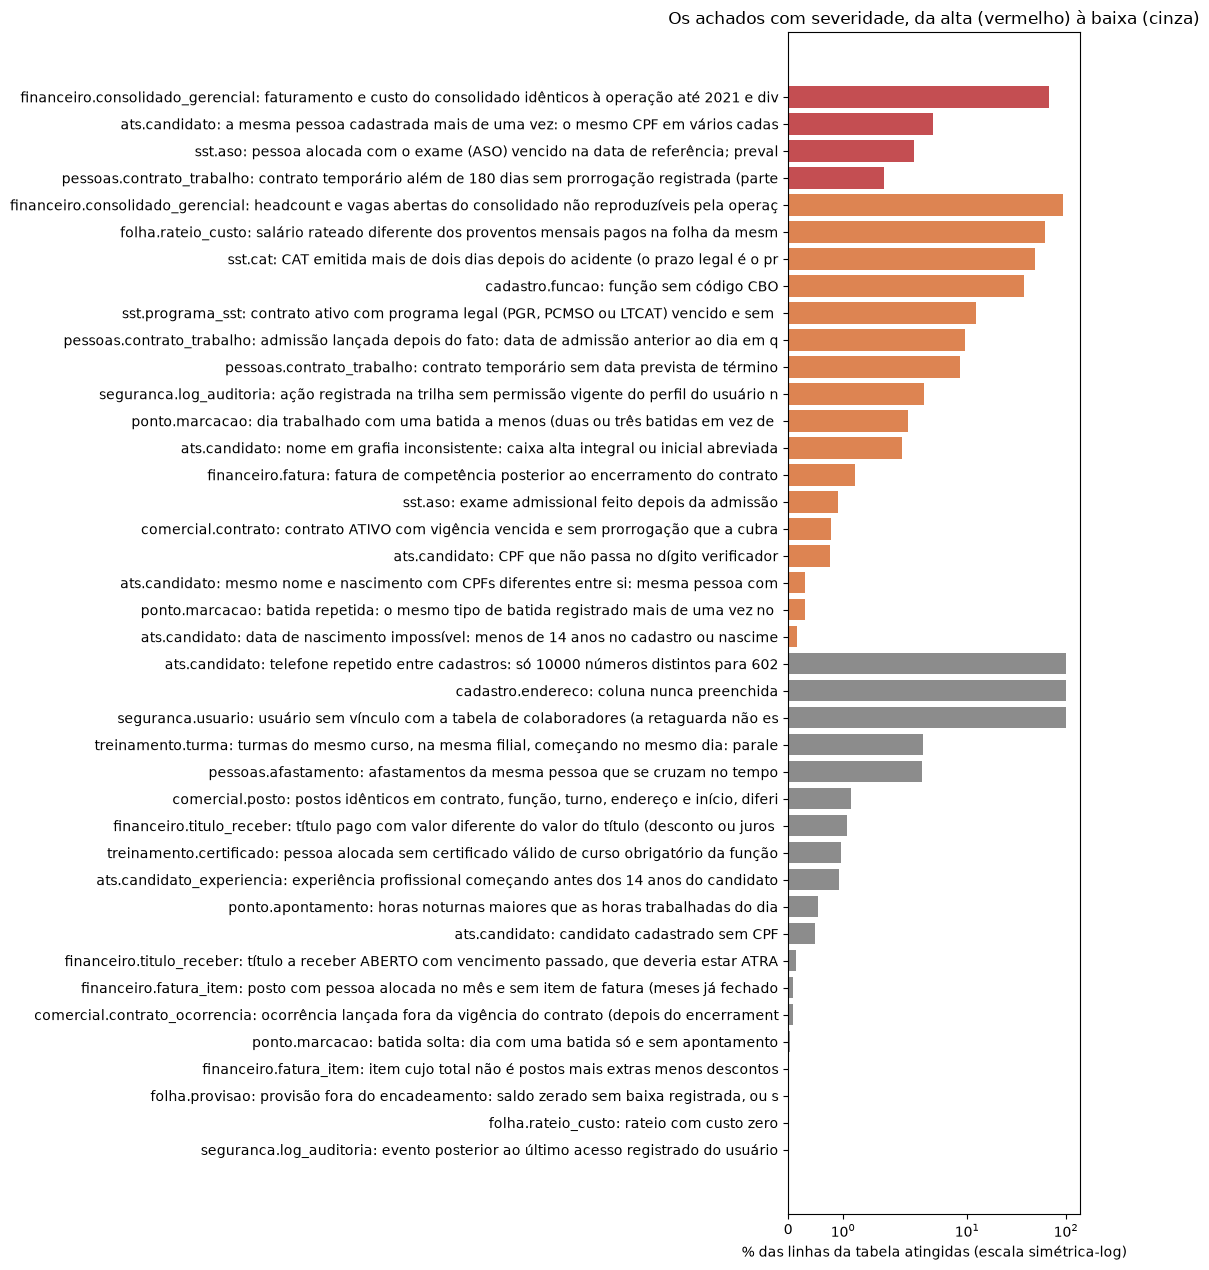

In [3]:
defeitos = quadro[quadro["severidade"] != "nenhuma"].copy()
defeitos["rotulo"] = defeitos["tabela"] + ": " + defeitos["achado"].str.slice(0, 70)
fig, eixo = plt.subplots(figsize=(11, max(4, 0.32 * len(defeitos))))
cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C"}
ordem = defeitos["severidade"].map({"alta": 0, "media": 1, "baixa": 2})
ordenado = defeitos.assign(_ordem=ordem).sort_values(["_ordem", "pct"], ascending=[True, False])
eixo.barh(ordenado["rotulo"][::-1], ordenado["pct"][::-1], color=[cores[s] for s in ordenado["severidade"][::-1]])
eixo.set_xlabel("% das linhas da tabela atingidas (escala simétrica-log)")
eixo.set_title("Os achados com severidade, da alta (vermelho) à baixa (cinza)")
eixo.set_xscale("symlog")
plt.tight_layout()
plt.show()

## Nota Técnica

**Observado:** 4 achados altos, 17 médios, 19 baixos e 21 registros de severidade nenhuma (hipóteses refutadas, regras de negócio que pareciam defeito e dois defeitos de pipeline já corrigidos). Os altos estão em quatro domínios diferentes: o consolidado da gerência (financeiro), o candidato duplicado (ats), o ASO vencido com pessoa em campo (SST) e o temporário além do prazo (pessoas). O `ats` e o `financeiro` são os domínios com mais achados (10 cada); o `cadastro` e o `comercial` os mais limpos. No gráfico, a fração de linhas atingidas vai de 61% (o salário rateado que não bate com a folha) a menos de 1% (a maioria dos achados de prazo e de status), e a severidade não segue a fração: o consolidado atinge 158 de 237 linhas e é o achado mais importante do projeto; o temporário fora do prazo atinge 1,7% e é o de maior consequência jurídica.

**Por que importa:** severidade e volume são eixos diferentes, e o catálogo precisa dos dois: o volume diz quanto trabalho a silver tem, a severidade diz o que decidir primeiro.

**Ação:** nenhuma; a tabela é a entrada da seção 5.

<a id="secao-3"></a>

# 3. As seis declarações do cliente

O `docs/02` lista o que o cliente já sabia que existia: candidatos duplicados, documentos inválidos, admissões retroativas, temporários fora do prazo, ASO vencido com pessoa alocada e o consolidado que diverge. Cada achado que testou uma declaração a cita; aqui elas são reunidas e recebem o veredito.

In [4]:
com_declaracao = quadro[quadro["declaracao"] != ""].copy()
def resumo(g):
    return pd.Series({
        "dominios": ", ".join(sorted(g["dominio"].unique())),
        "achados": len(g),
        "veredito": "confirmada" if (g["severidade"] != "nenhuma").any() else "refutada",
        "evidencia": "; ".join(f"{a} ({l:,} de {t:,})".replace(",", ".") for a, l, t in zip(g["achado"].str.slice(0, 60), g["linhas"], g["total"])),
    })
declaracoes = com_declaracao.groupby("declaracao").apply(resumo, include_groups=False).reset_index()
print(f"Declarações testadas: {len(declaracoes)}; confirmadas: {int((declaracoes['veredito'] == 'confirmada').sum())}")
declaracoes

Declarações testadas: 6; confirmadas: 6


,declaracao,dominios,achados,veredito,evidencia
0,ASO vencido com pessoa alocada: o exame expirou e ninguém foi avisado,treinamento_sst,1,confirmada,pessoa alocada com o exame (ASO) vencido na data de referênc (25 de 858)
1,"candidatos duplicados: a mesma pessoa cadastrada mais de uma vez, com grafias diferentes do nome e às vezes document...",ats,2,confirmada,a mesma pessoa cadastrada mais de uma vez: o mesmo CPF em vá (2.735 de 60.294); mesmo nome e nascimento com CPFs dif...
2,contratos temporários fora do prazo legal: passaram de 180 ou 270 dias sem aditivo registrado,pessoas,1,confirmada,contrato temporário além de 180 dias sem prorrogação registr (263 de 15.064)
3,"datas retroativas: admissões lançadas depois do fato, com data anterior à do próprio cadastro",pessoas,1,confirmada,admissão lançada depois do fato: data de admissão anterior a (1.621 de 16.992)
4,"documentos inválidos: CPF com dígito verificador errado, data de nascimento impossível","ats, pessoas",3,confirmada,CPF que não passa no dígito verificador (457 de 59.999); data de nascimento impossível: menos de 14 anos no cadastro...
5,o consolidado da gerência diverge da operação a partir de 2022 e a divergência cresce com o volume,financeiro,2,confirmada,faturamento e custo do consolidado idênticos à operação até (158 de 237); headcount e vagas abertas do consolidado ...


In [5]:
nao_declarados = quadro[(quadro["declaracao"] == "") & (quadro["severidade"].isin(["alta", "media"]))]
print(f"Achados altos ou médios que nenhuma declaração previa: {len(nao_declarados)}")
nao_declarados[["severidade", "dominio", "tabela", "achado", "linhas", "total", "pct"]]

Achados altos ou médios que nenhuma declaração previa: 12


,severidade,dominio,tabela,achado,linhas,total,pct
5,media,folha,folha.rateio_custo,"salário rateado diferente dos proventos mensais pagos na folha da mesma pessoa e mês (sempre um pouco abaixo; 1,7% a...",39104,63445,61.63
6,media,treinamento_sst,sst.cat,CAT emitida mais de dois dias depois do acidente (o prazo legal é o primeiro dia útil),48,99,48.48
7,media,cadastro,cadastro.funcao,função sem código CBO,17,45,37.78
8,media,treinamento_sst,sst.programa_sst,"contrato ativo com programa legal (PGR, PCMSO ou LTCAT) vencido e sem substituto",5,41,12.20
10,media,pessoas,pessoas.contrato_trabalho,contrato temporário sem data prevista de término,1281,15064,8.50
11,media,seguranca,seguranca.log_auditoria,ação registrada na trilha sem permissão vigente do perfil do usuário naquele dia (a maioria exportações),4092,111406,3.67
12,media,ponto,ponto.marcacao,dia trabalhado com uma batida a menos (duas ou três batidas em vez de quatro),26900,1080569,2.49
13,media,ats,ats.candidato,nome em grafia inconsistente: caixa alta integral ou inicial abreviada no meio,1333,60294,2.21
14,media,financeiro,financeiro.fatura,fatura de competência posterior ao encerramento do contrato,42,3459,1.21
15,media,treinamento_sst,sst.aso,exame admissional feito depois da admissão,155,16992,0.91


## Nota Técnica

**Observado:** **As seis declarações do cliente se confirmaram, todas com número.** Candidatos duplicados: 2.735 cadastros compartilham 1.349 CPFs, sempre com o nome em outra grafia, e 90 pares de nome e nascimento têm CPFs diferentes. Documentos inválidos: 457 CPFs não passam no dígito e 94 nascimentos são impossíveis, todos no cadastro de candidato; nenhum atravessou a admissão. Admissões retroativas: 1.621 (9,5%), subindo de 2,8% em 2018 para 11,8% em 2026. Temporários fora do prazo: 263 além de 180 dias sem prorrogação, 32 ainda ativos. ASO vencido com pessoa alocada: 25 hoje, com prevalência mensal de zero em 2018 a 4% em 2025. O consolidado da gerência: idêntico à operação até 2021 e divergente desde janeiro de 2022 em 158 de 237 meses-filial, com a diferença de faturamento chegando a 4,4% em 2026. E há o que ninguém declarou: 12 achados médios, entre eles o salário rateado que fica 1,7% abaixo do pago (a margem por cliente está superestimada), 4.092 ações na trilha sem permissão vigente, 26.900 dias de ponto com batida faltando, 1.281 temporários sem data prevista de término e 42 faturas de contrato já encerrado.

**Por que importa:** a auditoria às cegas cumpriu o que prometia: confirmou o que o cliente sabia sem consultar a resposta, mediu cada caso, e encontrou o que o cliente não sabia. O padrão que atravessa os domínios é um só: os cadastros e as chaves estão certos, e os processos com prazo (renovar exame, prorrogar contrato, lançar admissão, fechar o consolidado) deixaram de acompanhar o crescimento a partir de 2022 e 2023.

**Ação:** levar ao catálogo as seis declarações como confirmadas, com a evidência, e os doze achados não declarados como o que a auditoria acrescentou.

<a id="secao-4"></a>

# 4. Os defeitos do pipeline

A auditoria olhou a bronze como olharia o dado de um cliente, e por isso achou também o que era nosso: colunas que a ingestão gravou com o tipo errado. Estão registrados com severidade nenhuma porque já foram corrigidos, e ficam aqui para o catálogo saber que a bronze foi recopiada.

In [6]:
pipeline = quadro[quadro["achado"].str.startswith("defeito de ingestão")]
print(f"{len(pipeline)} defeitos de pipeline encontrados e corrigidos")
pipeline[["dominio", "tabela", "coluna", "achado", "acao"]]

2 defeitos de pipeline encontrados e corrigidos


,dominio,tabela,coluna,achado,acao
44,cadastro,cadastro.escala,"dias_ciclo, mes_data_base (e, em outros domínios, etapa_funil.ordem e titulo_receber.numero_parcela)",defeito de ingestão encontrado e corrigido: colunas TINYINT copiadas para a bronze como BOOLEAN (todo valor virava T...,"feito nesta auditoria: o backfill passou a mapear como booleano só o tinyint(1) que a DDL usa para BOOLEAN, e as qua..."
56,ponto,ponto.marcacao,hora,defeito de ingestão encontrado e corrigido: TIME copiado para a bronze como duração (BIGINT de microssegundos),feito nesta auditoria: o backfill grava TIME como time64 e a tabela foi recopiada; a checagem de tipo entrou em toda...


## Nota Técnica

**Observado:** dois defeitos de ingestão, os dois no mapeamento de tipos do backfill: quatro colunas `TINYINT` copiadas como booleano (todo valor virava `True`) e a hora da marcação de ponto copiada como duração (um inteiro de microssegundos). Os dois foram corrigidos no código, provados por teste, e as cinco tabelas recopiadas; a checagem de tipo contra a DDL passou a fazer parte de toda auditoria.

**Por que importa:** a régua de conservação (C-06) só conta linhas, e nenhuma contagem acusa tipo errado. A auditoria que olha o dado do cliente é também a que olha o que o pipeline fez com ele.

**Ação:** nenhuma além do já feito; a lição está no worklog e entra na documentação da bronze.

<a id="secao-5"></a>

# 5. O catálogo preliminar

Os achados com severidade, da alta para a baixa, com o impacto e a ação proposta. É a entrada do catálogo de achados: cada linha vira uma regra proposta, e nenhuma regra é aplicada antes da aprovação.

In [7]:
catalogo = quadro[quadro["severidade"] != "nenhuma"][["severidade", "dominio", "tabela", "coluna", "achado", "linhas", "total", "pct", "impacto", "acao", "declaracao"]].reset_index(drop=True)
catalogo.index = catalogo.index + 1
print(f"{len(catalogo)} achados para o catálogo: {(catalogo['severidade'] == 'alta').sum()} altos, {(catalogo['severidade'] == 'media').sum()} médios, {(catalogo['severidade'] == 'baixa').sum()} baixos")
catalogo[["severidade", "dominio", "tabela", "achado", "linhas", "total", "pct"]]

40 achados para o catálogo: 4 altos, 17 médios, 19 baixos


,severidade,dominio,tabela,achado,linhas,total,pct
1,alta,financeiro,financeiro.consolidado_gerencial,"faturamento e custo do consolidado idênticos à operação até 2021 e divergentes desde 01/2022, com a diferença cresce...",158,237,66.67
2,alta,ats,ats.candidato,"a mesma pessoa cadastrada mais de uma vez: o mesmo CPF em vários cadastros, com o nome em outra grafia",2735,60294,4.54
3,alta,treinamento_sst,sst.aso,pessoa alocada com o exame (ASO) vencido na data de referência; prevalência mensal crescendo de zero em 2018 a cerca...,25,858,2.91
4,alta,pessoas,pessoas.contrato_trabalho,contrato temporário além de 180 dias sem prorrogação registrada (parte deles ainda ativos; parte além de 270 dias no...,263,15064,1.75
5,media,financeiro,financeiro.consolidado_gerencial,"headcount e vagas abertas do consolidado não reproduzíveis pela operação em nenhum ano, desde 2018: definição não es...",220,237,92.83
6,media,folha,folha.rateio_custo,"salário rateado diferente dos proventos mensais pagos na folha da mesma pessoa e mês (sempre um pouco abaixo; 1,7% a...",39104,63445,61.63
7,media,treinamento_sst,sst.cat,CAT emitida mais de dois dias depois do acidente (o prazo legal é o primeiro dia útil),48,99,48.48
8,media,cadastro,cadastro.funcao,função sem código CBO,17,45,37.78
9,media,treinamento_sst,sst.programa_sst,"contrato ativo com programa legal (PGR, PCMSO ou LTCAT) vencido e sem substituto",5,41,12.20
10,media,pessoas,pessoas.contrato_trabalho,admissão lançada depois do fato: data de admissão anterior ao dia em que o registro foi criado,1621,16992,9.54


In [8]:
catalogo[["severidade", "tabela", "impacto", "acao"]]

,severidade,tabela,impacto,acao
1,alta,financeiro.consolidado_gerencial,"dois números para a mesma pergunta; a decisão sobre qual é a fonte da verdade é do dono do processo, e a prova de qu...","a gold usa a operação como fonte da verdade para faturamento e custo e guarda o consolidado como série informada, la..."
2,alta,ats.candidato,"infla a base de talentos, divide o histórico da pessoa, distorce a conversão por fonte e conta a mesma pessoa mais d...","a silver marca o grupo de duplicidade por CPF e elege um cadastro canônico, sem fundir: a autoridade sobre o cadastr..."
3,alta,sst.aso,risco jurídico imediato para a Fictalent e para o cliente; o processo de renovação do periódico não acompanhou o cre...,a silver marca a pessoa e os dias de vencimento; o alerta vai para o painel com 30 dias de antecedência; o cliente r...
4,alta,pessoas.contrato_trabalho,irregularidade trabalhista com multa e risco de vínculo; a concentração recente diz que o controle se perdeu com o c...,a silver marca o contrato e os dias além do prazo; o alerta vai para o painel; o cliente regulariza na origem
5,media,financeiro.consolidado_gerencial,o número que a gerência reporta não tem definição que o pipeline consiga recalcular,pedir à gerente a definição de headcount e de vaga aberta e escrevê-la; até lá a gold reporta os dois números com a ...
6,media,folha.rateio_custo,o rateio é a base da margem por cliente; salário rateado menor que o pago faz a margem de cada contrato parecer maio...,o catálogo pede ao cliente a regra do rateio; a silver marca a diferença por pessoa-mês e não corrige
7,media,sst.cat,multa por CAT fora do prazo,a silver marca os dias além do prazo; o cliente corrige o processo
8,media,cadastro.funcao,"o CBO é o código de ocupação do eSocial e o que liga a função às estatísticas públicas de emprego; sem ele, 17 funçõ...",pedir os códigos ao cliente; na silver a ausência não se preenche (inventar CBO cria dado que ninguém coletou)
9,media,sst.programa_sst,irregularidade em contrato em andamento; autuação para a Fictalent e para o cliente,a silver marca o contrato; o alerta vai para o painel; o cliente renova o programa
10,media,pessoas.contrato_trabalho,"headcount e custo do mês ficam errados até o lançamento, e a proporção sobe ano a ano: o processo está piorando com ...",a silver marca admissao_retroativa e os dias de atraso; a gold usa a data de admissão como fato; o cliente acompanha...


In [9]:
registrados = quadro[quadro["severidade"] == "nenhuma"][["dominio", "tabela", "achado"]].reset_index(drop=True)
print(f"{len(registrados)} registros de severidade nenhuma (hipóteses refutadas, regras e pontos fortes):")
registrados

21 registros de severidade nenhuma (hipóteses refutadas, regras e pontos fortes):


,dominio,tabela,achado
0,ponto,ponto.marcacao,"jornada noturna que vira a meia-noite: saída com hora menor que a entrada no mesmo dia (não é defeito, é o turno da ..."
1,seguranca,seguranca.log_auditoria,"exportações de dado pessoal crescendo em número e em peso (de 11.74% para 24.64% dos eventos), concentradas no perfi..."
2,ats,ats.candidatura,candidatura aprovada que não virou colaborador: o no-show do primeiro dia de trabalho
3,ats,ats.candidatura_etapa,"hipótese refutada: nenhuma etapa fora de ordem, fora da candidatura ou com data invertida"
4,cadastro,cadastro.escala,defeito de ingestão encontrado e corrigido: colunas TINYINT copiadas para a bronze como BOOLEAN (todo valor virava T...
5,cadastro,cadastro.endereco,hipótese refutada: não há endereço nem outro cadastro de referência duplicado por conteúdo
6,cadastro,cadastro.feriado,feriados nacionais conferidos contra a BrasilAPI só nos anos que a fonte tem no lake (2024): 14 de 14; os demais ano...
7,comercial,comercial.cliente,hipótese refutada: não há cliente duplicado por grafia nem CNPJ repetido
8,financeiro,financeiro.fatura,"faturas sem item: todas de contratos de recrutamento, que faturam honorário por colocação e não posto por mês (regra..."
9,financeiro,financeiro.imposto_apurado,apurações trimestrais de IRPJ com alíquota efetiva acima da tabela: é o adicional de 10% sobre o lucro que excede o ...


## Nota Técnica

**Observado:** 40 achados para o catálogo (4 altos, 17 médios, 19 baixos), cada um com tabela, coluna, linhas atingidas, impacto e ação proposta, e 21 registros de severidade nenhuma que dizem o que **não** tratar: as hipóteses refutadas (nenhum órfão, nenhuma alocação dupla, totais que batem), as regras que pareciam defeito (jornada noturna que vira a meia-noite, adicional de IRPJ, fatura de honorário sem posto, desistência com motivo) e os pontos fortes.

**Por que importa:** o catálogo é a decisão, e decisão precisa de proposta: cada linha aqui já diz o que a silver faria (marcar, derivar, conformar; nunca fundir, nunca preencher ausência, nunca apagar) para o Tiago aprovar, ajustar ou recusar. Os registros de severidade nenhuma evitam que a silver trate como erro o que é regra.

**Ação:** o passo seguinte (6.3) escreve o catálogo de achados a partir desta tabela, com as duas redações (executiva e técnica) por achado, e o submete à aprovação antes de qualquer transformação.

<a id="secao-6"></a>

# 6. Fechamento

O veredito da auditoria inteira.

## Nota Técnica de fechamento

**O que foi examinado:** as 75 tabelas de negócio da bronze, em nove notebooks de domínio e 61 achados, sobre a carga de 24/09/2026. Cada domínio passou por tipo, completude, unicidade, domínios declarados, texto, cronologia, integridade referencial e as regras do negócio, com as declarações do cliente testadas como hipóteses.

**O veredicto da auditoria: a estrutura está certa e os processos com prazo não acompanharam o crescimento.** Chaves, referências, domínios, aritmética da folha e da fatura, cronologia do funil e do vínculo passaram inteiros. Os defeitos são de cadastro de candidato (duplicidade por grafia, documento inválido), de prazo (exame, contrato temporário, admissão, CAT, programa legal, status de contrato e de título) e de fechamento (o consolidado da gerência e o rateio da folha). As seis declarações se confirmaram com número e doze achados médios foram acrescentados. A auditoria achou também dois defeitos do próprio pipeline, corrigidos no ato.

**Próximos passos:** o catálogo de achados (6.3), com as duas redações por achado e a regra proposta, para aprovação antes de qualquer transformação; a silver (6.4) só existe depois dele.